# Excess Free Energy Plot

Demonstrates `plot_excess_free_energy` with three `SlowInterpolatingPhase` solid-solution
phases and one `LinePhase` intermetallic.

The excess free energy is defined with respect to a linear reference connecting the
lowest-energy phases at c=0 and c=1 (auto-detected per temperature).  Solution phases
render as curves; line phases render as scatter points.  The dashed black line is the
lower convex hull (common-tangent construction).

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 100

import landau
from landau import LinePhase, SlowInterpolatingPhase, plot_excess_free_energy

## Build phases

Three `SlowInterpolatingPhase` solid-solution phases span the concentration range:

| Phase   | Type                    | c range      | Description |
|---------|-------------------------|--------------|-------------|
| AlphaA  | `SlowInterpolatingPhase` | [0.00, 0.45] | A-rich solid solution |
| AlphaB  | `SlowInterpolatingPhase` | [0.30, 0.70] | Mid solid solution |
| AlphaC  | `SlowInterpolatingPhase` | [0.55, 1.00] | B-rich solid solution |
| B2      | `LinePhase`             | c = 0.50     | Ordered intermetallic |

End members at c=0 and c=1 are covered by AlphaA and AlphaC respectively, so
no separate end-member `LinePhase` objects are needed.

In [2]:
# AlphaA: A-rich solid solution, c in [0.00, 0.45]
alphaA_points = [
    LinePhase(name='aA@0.00', fixed_concentration=0.00, line_energy=-1.000),
    LinePhase(name='aA@0.10', fixed_concentration=0.10, line_energy=-1.035),
    LinePhase(name='aA@0.20', fixed_concentration=0.20, line_energy=-1.060),
    LinePhase(name='aA@0.30', fixed_concentration=0.30, line_energy=-1.055),
    LinePhase(name='aA@0.40', fixed_concentration=0.40, line_energy=-1.030),
    LinePhase(name='aA@0.45', fixed_concentration=0.45, line_energy=-1.010),
]
alpha_a = SlowInterpolatingPhase(name='AlphaA', phases=alphaA_points)

# AlphaB: mid solid solution, c in [0.30, 0.70]
alphaB_points = [
    LinePhase(name='aB@0.30', fixed_concentration=0.30, line_energy=-1.070),
    LinePhase(name='aB@0.40', fixed_concentration=0.40, line_energy=-1.100),
    LinePhase(name='aB@0.50', fixed_concentration=0.50, line_energy=-1.120),
    LinePhase(name='aB@0.60', fixed_concentration=0.60, line_energy=-1.095),
    LinePhase(name='aB@0.70', fixed_concentration=0.70, line_energy=-1.060),
]
alpha_b = SlowInterpolatingPhase(name='AlphaB', phases=alphaB_points)

# AlphaC: B-rich solid solution, c in [0.55, 1.00]
alphaC_points = [
    LinePhase(name='aC@0.55', fixed_concentration=0.55, line_energy=-1.020),
    LinePhase(name='aC@0.65', fixed_concentration=0.65, line_energy=-0.990),
    LinePhase(name='aC@0.75', fixed_concentration=0.75, line_energy=-0.955),
    LinePhase(name='aC@0.85', fixed_concentration=0.85, line_energy=-0.910),
    LinePhase(name='aC@1.00', fixed_concentration=1.00, line_energy=-0.820),
]
alpha_c = SlowInterpolatingPhase(name='AlphaC', phases=alphaC_points)

# B2: ordered intermetallic at c = 0.50
b2 = LinePhase(name='B2', fixed_concentration=0.50, line_energy=-1.200)

phases = [alpha_a, alpha_b, alpha_c, b2]

print('Phases:', [p.name for p in phases])
print('AlphaA range:', alpha_a.concentration_range)
print('AlphaB range:', alpha_b.concentration_range)
print('AlphaC range:', alpha_c.concentration_range)

Phases: ['AlphaA', 'AlphaB', 'AlphaC', 'B2']
AlphaA range: (0, 0.45)
AlphaB range: (0.3, 0.7)
AlphaC range: (0.55, 1)


## Plot excess free energy at multiple temperatures

* Three `SlowInterpolatingPhase` objects appear as **smooth curves**
* `B2` `LinePhase` appears as a single **scatter point**
* **Dashed black line** = lower convex hull (common-tangent construction)

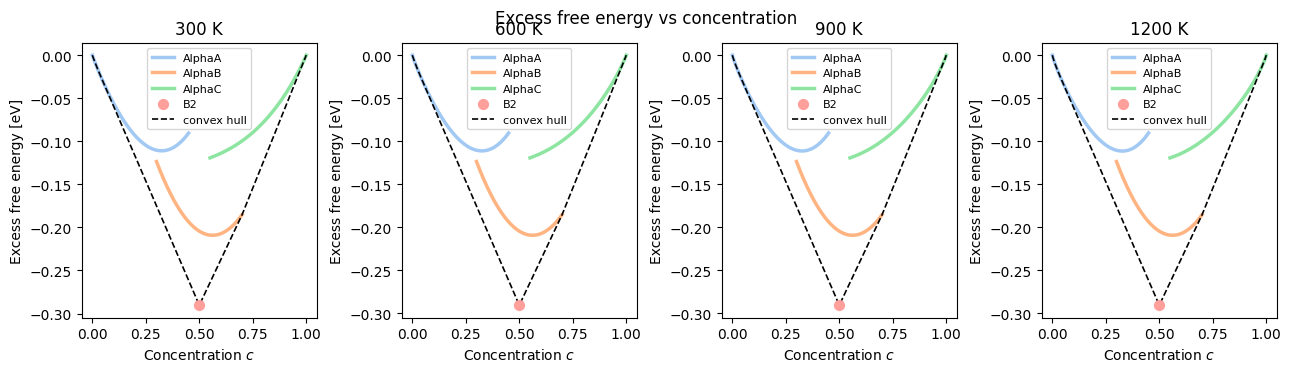

In [3]:
fig, axes = plot_excess_free_energy(
    phases,
    temperatures=[300, 600, 900, 1200],
    max_cols=4,
    sharey=False,
    linewidth=2.5,
    per_col_in=3.2,
    per_row_in=3.5,
)
fig.suptitle('Excess free energy vs concentration', y=1.02)
plt.show()

## Single temperature

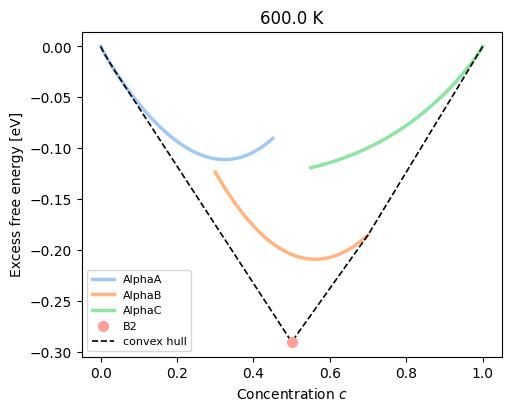

In [4]:
fig2, axes2 = plot_excess_free_energy(
    phases,
    temperatures=600,
    max_cols=1,
    sharey=False,
    linewidth=2.5,
    per_col_in=5.0,
    per_row_in=4.0,
)
plt.show()